# CTAP vs Local Pipeline Comparison

This notebook compares the archived CTAP human benchmark exports against the current local-only evaluation pipeline.

Its purpose is not to force exact numeric equality. The two pipelines aggregate lexical features differently. The useful question is whether they preserve the same comparative signal between the Advanced and Elementary texts.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"

CTAP_ADV_PATH = DATA / "advResults"
CTAP_ELEM_PATH = DATA / "elemResults"
LOCAL_TEXT_PATH = OUTPUTS / "human_baseline_text_metrics.csv"
LOCAL_PAIRWISE_PATH = OUTPUTS / "human_baseline_pairwise_comparisons.csv"

for path in [CTAP_ADV_PATH, CTAP_ELEM_PATH, LOCAL_TEXT_PATH, LOCAL_PAIRWISE_PATH]:
    print(f"{'OK' if path.exists() else 'MISSING'}  {path}")

OK  D:\Year-3-Uni\thesis\Code\LGP-score\data\advResults
OK  D:\Year-3-Uni\thesis\Code\LGP-score\data\elemResults
OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\human_baseline_text_metrics.csv
OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\human_baseline_pairwise_comparisons.csv


In [2]:
CTAP_FEATURE_MAP = {
    "Lexical Sophistication Feature: Age of Acquisition (LW Type)": "aoa",
    "Lexical Sophistication Feature: Concreteness (LW Type)": "concreteness",
    "Lexical Sophistication Feature: Imageability (LW Type)": "imageability",
    "Readability: Flesch-Kincaid Grade Level": "fk_grade",
    "Lexical Diversity: Measure of Textual Lexical Diversity (MTLD)": "mtld",
}


def normalize_story_key(value: str) -> str:
    text = str(value).strip().lower()
    text = re.sub(r"\.txt$", "", text)
    text = re.sub(r"-(adv|ele|int)$", "", text)
    text = re.sub(r"^wnl\s+", "", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def load_ctap_export(path: Path, level: str) -> pd.DataFrame:
    raw = pd.read_csv(path, sep="\t").copy()
    raw = raw[raw["Feature_Name"].isin(CTAP_FEATURE_MAP)].copy()
    raw["metric"] = raw["Feature_Name"].map(CTAP_FEATURE_MAP)
    raw["story_key"] = raw["Text_Title"].astype(str).map(normalize_story_key)
    raw["Value"] = pd.to_numeric(raw["Value"], errors="coerce")
    pivot = (
        raw.pivot_table(index=["story_key", "Text_Title"], columns="metric", values="Value", aggfunc="mean")
        .reset_index()
        .rename_axis(None, axis=1)
    )
    pivot["level"] = level
    pivot["source"] = "ctap"
    return pivot


def load_local_human(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    df = df[df["source_type"] == "human_reference"].copy()
    df["story_key"] = df["story_key"].astype(str).map(normalize_story_key)
    keep = ["story_key", "story_id", "level", "aoa", "concreteness", "imageability", "fk_grade", "mtld", "cli", "tier2_proxy_token_ratio"]
    df = df[keep].copy()
    df["source"] = "local"
    return df


ctap_adv = load_ctap_export(CTAP_ADV_PATH, "Advanced")
ctap_elem = load_ctap_export(CTAP_ELEM_PATH, "Elementary")
ctap = pd.concat([ctap_adv, ctap_elem], ignore_index=True)
local_human = load_local_human(LOCAL_TEXT_PATH)

display(ctap.head())
display(local_human.head())

,story_key,Text_Title,aoa,concreteness,fk_grade,imageability,mtld,level,source
0,101 year old bottle message,WNL 101 year old bottle message-adv.txt,322.375,367.796,8.902,404.475,66.284,Advanced,ctap
1,a good night sleep,WNL A good night sleep-adv.txt,340.435,365.603,8.599,396.507,77.716,Advanced,ctap
2,amazon,Amazon-adv.txt,410.600,374.743,11.066,407.705,108.286,Advanced,ctap
3,amsterdam,Amsterdam-adv.txt,391.806,353.338,12.359,390.486,124.642,Advanced,ctap
4,anita,Anita-adv.txt,387.200,372.128,10.306,409.106,122.043,Advanced,ctap


,story_key,story_id,level,aoa,concreteness,imageability,fk_grade,mtld,cli,tier2_proxy_token_ratio,source
0,amazon,Amazon,Elementary,401.517,339.408,371.824,8.731,88.034,-1.189,0.164,local
1,amazon,Amazon,Intermediate,412.889,344.457,372.688,10.283,98.923,-1.289,0.174,local
2,amazon,Amazon,Advanced,411.261,350.151,376.426,11.066,108.286,-1.126,0.167,local
3,amsterdam,Amsterdam,Elementary,376.278,337.111,365.042,9.599,82.468,-0.916,0.026,local
4,amsterdam,Amsterdam,Intermediate,393.442,335.848,366.510,11.644,108.401,-1.188,0.055,local


## Overall Means

The first check is whether the two pipelines show the same directional pattern at corpus level.

In [3]:
ctap_summary = ctap.groupby("level")[["aoa", "concreteness", "imageability", "fk_grade", "mtld"]].mean().reset_index()
ctap_summary["pipeline"] = "ctap"

local_summary = local_human.groupby("level")[["aoa", "concreteness", "imageability", "fk_grade", "mtld", "cli", "tier2_proxy_token_ratio"]].mean().reset_index()
local_summary["pipeline"] = "local"

display(ctap_summary)
display(local_summary)

,level,aoa,concreteness,imageability,fk_grade,mtld,pipeline
0,Advanced,365.426,372.214,401.921,11.126,109.866,ctap
1,Elementary,346.320,364.982,396.591,8.198,84.358,ctap


,level,aoa,concreteness,imageability,fk_grade,mtld,cli,tier2_proxy_token_ratio,pipeline
0,Advanced,359.450,355.626,383.006,11.131,110.285,-0.117,0.096,local
1,Elementary,340.944,355.620,383.269,8.156,83.927,0.185,0.069,local
2,Intermediate,355.029,354.853,382.183,9.843,99.837,-0.069,0.088,local


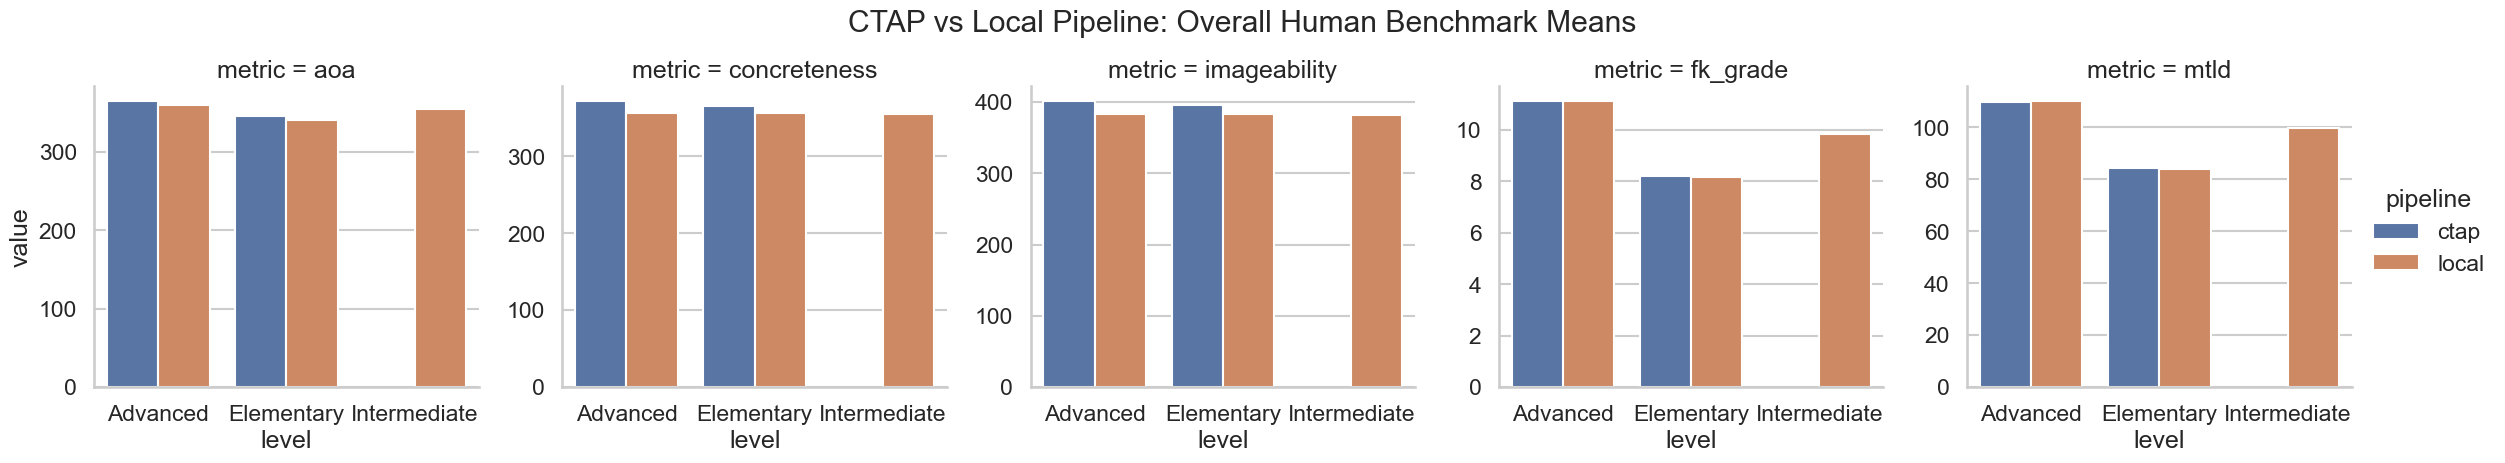

In [4]:
shared_metrics = ["aoa", "concreteness", "imageability", "fk_grade", "mtld"]
comparison_overall = pd.concat([
    ctap_summary[["level", "pipeline", *shared_metrics]],
    local_summary[["level", "pipeline", *shared_metrics]],
], ignore_index=True)

plot_df = comparison_overall.melt(id_vars=["level", "pipeline"], var_name="metric", value_name="value")
g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="level",
    y="value",
    hue="pipeline",
    col="metric",
    sharey=False,
    height=4.8,
    aspect=1.0,
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("CTAP vs Local Pipeline: Overall Human Benchmark Means")
plt.show()

## Pairwise Match on Shared Story Keys

This section tries to align the archived CTAP export titles with the local story keys. The match is approximate but usually good enough for a trend check.

In [5]:
ctap_wide = ctap[["story_key", "level", *shared_metrics]].copy()
local_wide = local_human[["story_key", "level", *shared_metrics, "cli", "tier2_proxy_token_ratio"]].copy()

matched = ctap_wide.merge(local_wide, on=["story_key", "level"], suffixes=("_ctap", "_local"))
print(f"Matched rows: {len(matched)}")
display(matched.head())

Matched rows: 386


,story_key,level,aoa_ctap,concreteness_ctap,imageability_ctap,fk_grade_ctap,mtld_ctap,aoa_local,concreteness_local,imageability_local,fk_grade_local,mtld_local,cli,tier2_proxy_token_ratio
0,101 year old bottle message,Advanced,322.375,367.796,404.475,8.902,66.284,300.415,360.576,387.064,8.902,66.284,0.965,0.057
1,a good night sleep,Advanced,340.435,365.603,396.507,8.599,77.716,340.344,354.087,388.926,8.599,77.716,0.258,0.127
2,amazon,Advanced,410.600,374.743,407.705,11.066,108.286,411.261,350.151,376.426,11.066,108.286,-1.126,0.167
3,amsterdam,Advanced,391.806,353.338,390.486,12.359,124.642,397.757,331.768,363.483,12.359,124.642,-1.361,0.051
4,anita,Advanced,387.200,372.128,409.106,10.306,122.043,385.969,357.762,392.506,10.317,118.750,-0.372,0.107


In [6]:
agreement_rows = []
for metric in shared_metrics:
    corr = matched[f"{metric}_ctap"].corr(matched[f"{metric}_local"])
    agreement_rows.append({
        "metric": metric,
        "pearson_r": corr,
        "ctap_mean": matched[f"{metric}_ctap"].mean(),
        "local_mean": matched[f"{metric}_local"].mean(),
    })

agreement_df = pd.DataFrame(agreement_rows).sort_values("pearson_r", ascending=False)
display(agreement_df)

,metric,pearson_r,ctap_mean,local_mean
3,fk_grade,0.978,9.648,9.631
4,mtld,0.943,97.182,97.176
0,aoa,0.844,355.834,350.263
2,imageability,0.692,399.483,383.302
1,concreteness,0.655,368.841,355.761


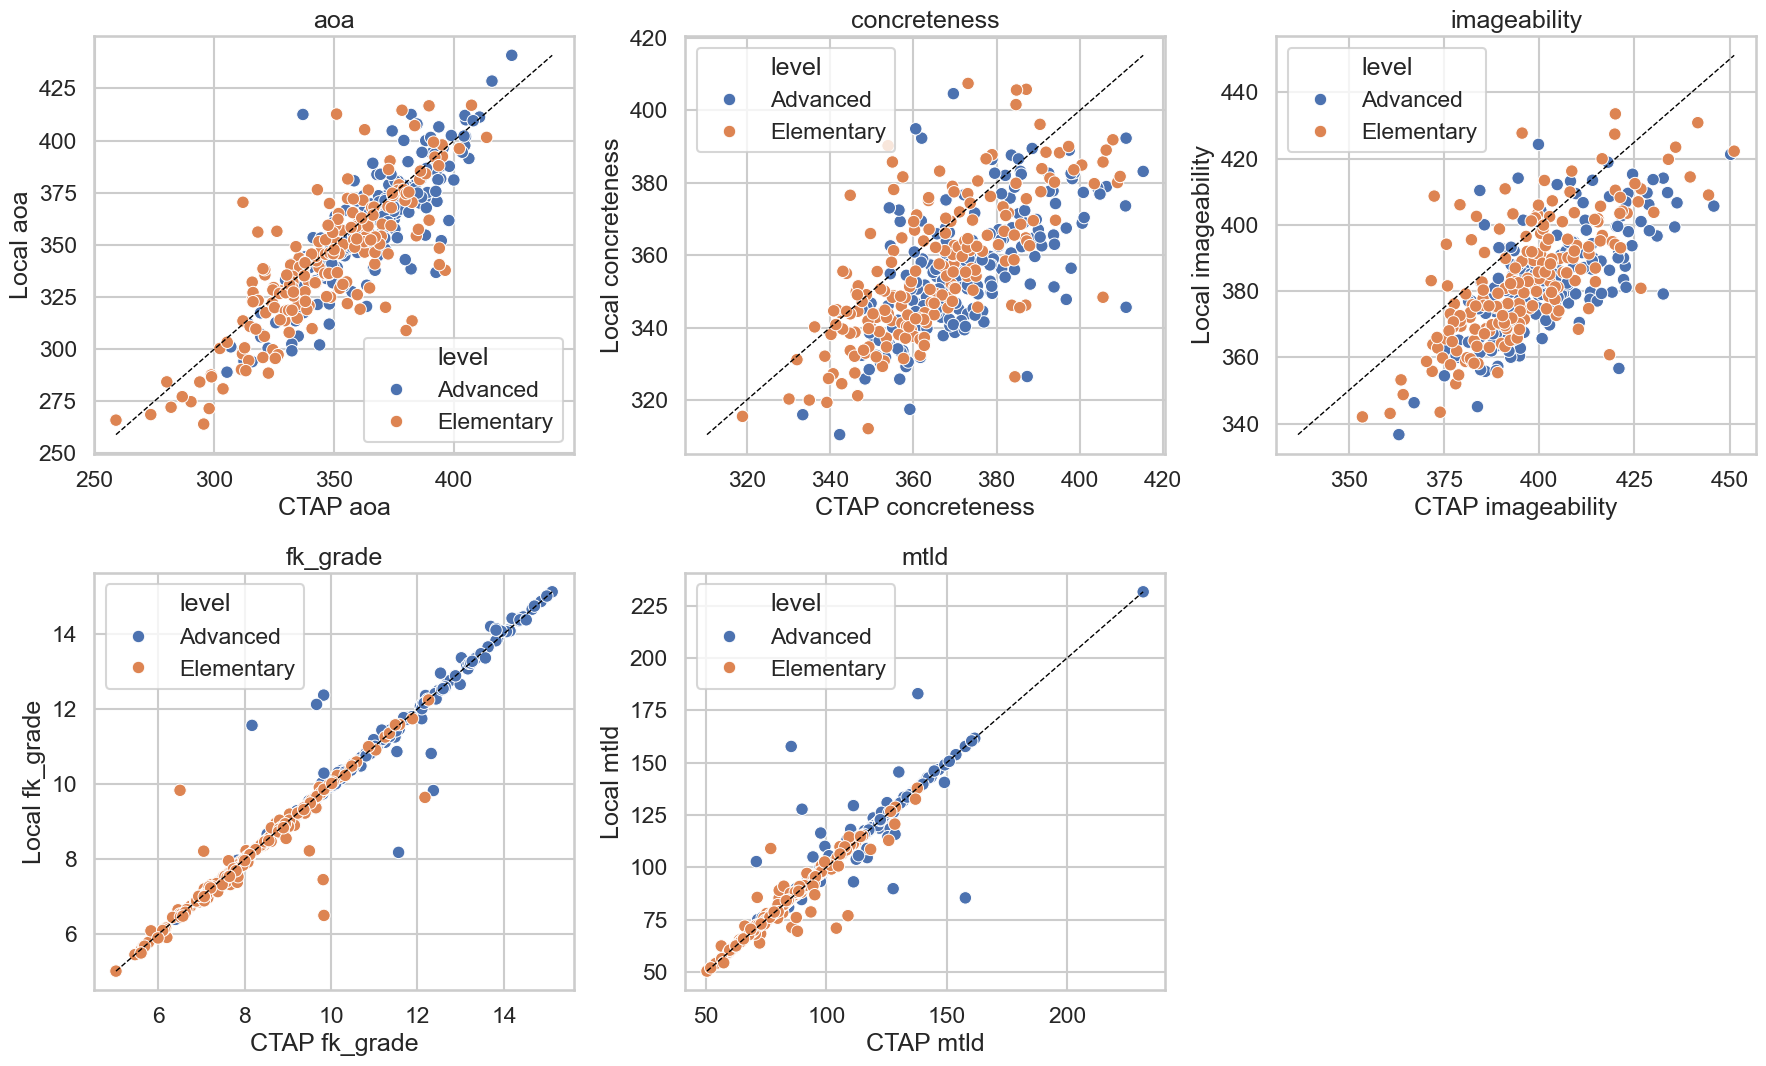

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for index, metric in enumerate(shared_metrics):
    ax = axes[index]
    sns.scatterplot(
        data=matched,
        x=f"{metric}_ctap",
        y=f"{metric}_local",
        hue="level",
        ax=ax,
    )
    min_val = np.nanmin([matched[f"{metric}_ctap"].min(), matched[f"{metric}_local"].min()])
    max_val = np.nanmax([matched[f"{metric}_ctap"].max(), matched[f"{metric}_local"].max()])
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", linewidth=1)
    ax.set_title(metric)
    ax.set_xlabel(f"CTAP {metric}")
    ax.set_ylabel(f"Local {metric}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Direction-of-Change Comparison

This is the most important sanity check for the thesis: does each pipeline tell the same story about how Elementary differs from Advanced?

In [8]:
ctap_delta = (
    ctap.pivot(index="story_key", columns="level", values=shared_metrics)
    .reset_index()
)
ctap_delta.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in ctap_delta.columns]

for metric in shared_metrics:
    ctap_delta[f"delta_{metric}"] = ctap_delta[f"{metric}_Elementary"] - ctap_delta[f"{metric}_Advanced"]

local_delta = (
    local_human.pivot(index="story_key", columns="level", values=shared_metrics + ["cli", "tier2_proxy_token_ratio"])
    .reset_index()
)
local_delta.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in local_delta.columns]

for metric in shared_metrics + ["cli", "tier2_proxy_token_ratio"]:
    local_delta[f"delta_{metric}"] = local_delta[f"{metric}_Elementary"] - local_delta[f"{metric}_Advanced"]

delta_rows = []
for metric in shared_metrics:
    delta_rows.append({
        "metric": metric,
        "ctap_mean_delta": ctap_delta[f"delta_{metric}"].mean(),
        "local_mean_delta": local_delta[f"delta_{metric}"].mean(),
        "same_direction": np.sign(ctap_delta[f"delta_{metric}"].mean()) == np.sign(local_delta[f"delta_{metric}"].mean()),
    })

delta_rows.append({
    "metric": "cli",
    "ctap_mean_delta": np.nan,
    "local_mean_delta": local_delta["delta_cli"].mean(),
    "same_direction": np.nan,
})
delta_rows.append({
    "metric": "tier2_proxy_token_ratio",
    "ctap_mean_delta": np.nan,
    "local_mean_delta": local_delta["delta_tier2_proxy_token_ratio"].mean(),
    "same_direction": np.nan,
})

delta_summary = pd.DataFrame(delta_rows)
display(delta_summary)

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
delta_plot = delta_summary[delta_summary["metric"].isin(shared_metrics)].melt(
    id_vars="metric",
    value_vars=["ctap_mean_delta", "local_mean_delta"],
    var_name="pipeline",
    value_name="mean_delta",
)
delta_plot["pipeline"] = delta_plot["pipeline"].str.replace("_mean_delta", "", regex=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=delta_plot, x="metric", y="mean_delta", hue="pipeline")
plt.axhline(0, color="black", linewidth=1)
plt.title("Advanced-to-Elementary Mean Delta: CTAP vs Local Pipeline")
plt.ylabel("Elementary minus Advanced")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Export Tables for Appendix or Notes

In [ ]:
export_dir = OUTPUTS / "appendix_tables"
export_dir.mkdir(parents=True, exist_ok=True)

ctap_summary.to_csv(export_dir / "ctap_human_overall_means.csv", index=False)
local_summary.to_csv(export_dir / "local_human_overall_means.csv", index=False)
agreement_df.to_csv(export_dir / "ctap_vs_local_metric_agreement.csv", index=False)
delta_summary.to_csv(export_dir / "ctap_vs_local_mean_deltas.csv", index=False)

print(f"Saved comparison tables to: {export_dir}")